# Final Project - Ruby Mayrose

### Read an example image from a FITS file and display it

In [10]:
import numpy as np
import sep

In [27]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [28]:
with fits.open('stars.fits') as hdul:
    data = hdul[0].data

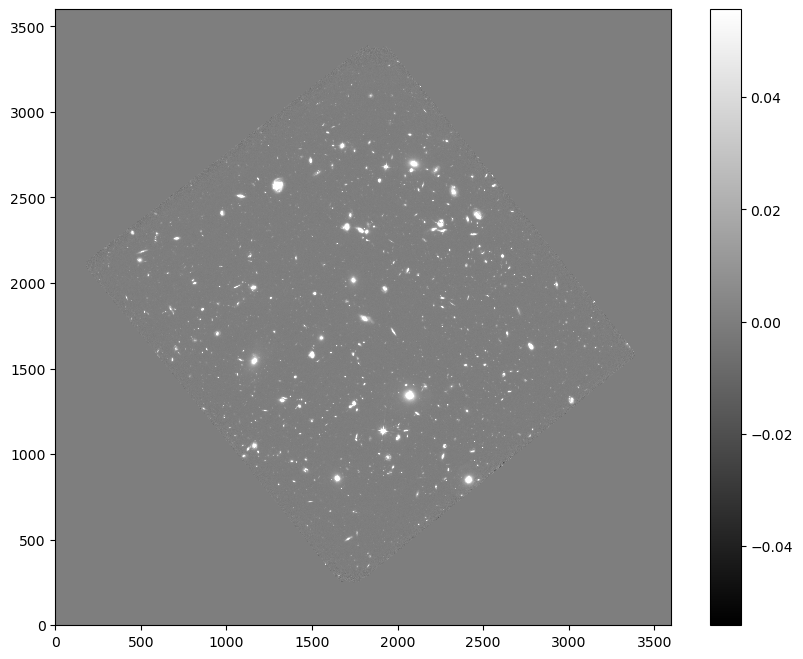

In [76]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();
plt.savefig('display1.png')

### Background Subtraction

In [77]:
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

In [78]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [79]:
bkg_image = bkg.back()

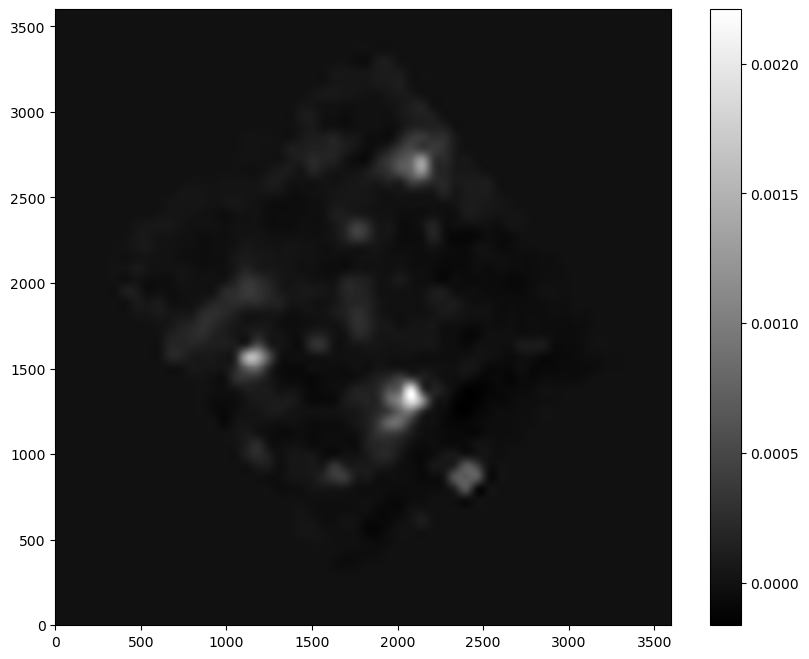

In [80]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig('display2.png')

In [81]:
bkg_rms = bkg.rms()

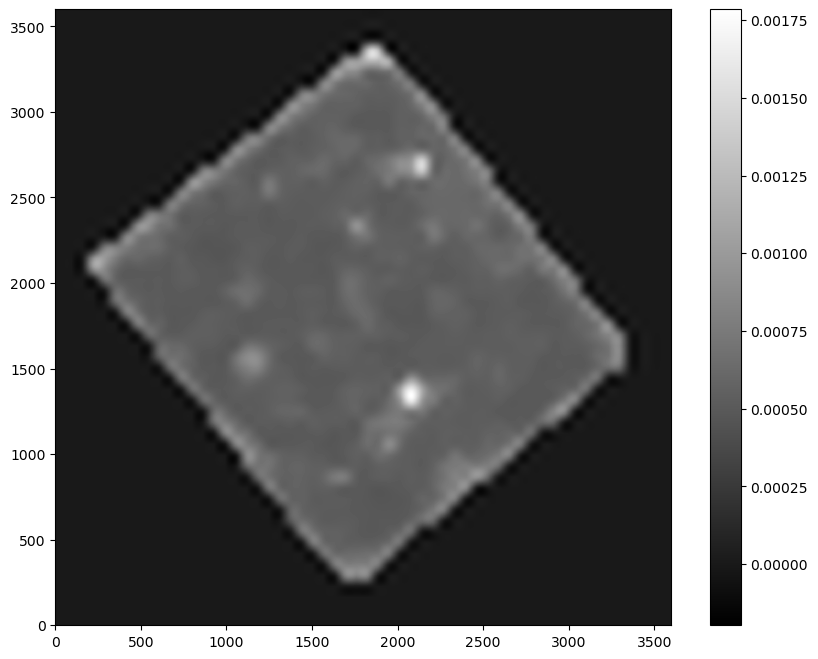

In [83]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig('display3.png')

In [84]:
data_sub = data - bkg

### Object Detection

In [85]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [86]:
len(objects)

8641

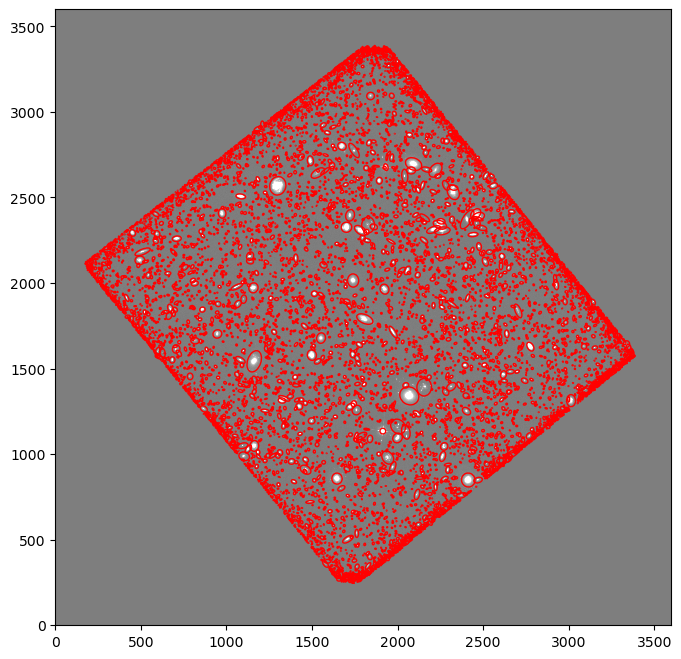

In [87]:
from matplotlib.patches import Ellipse
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig('display4.png')

In [88]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

### Aperture Photometry

In [89]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [90]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


# Questions

1. I found 8640 stars in the data, my histogram of their fluxes is below.

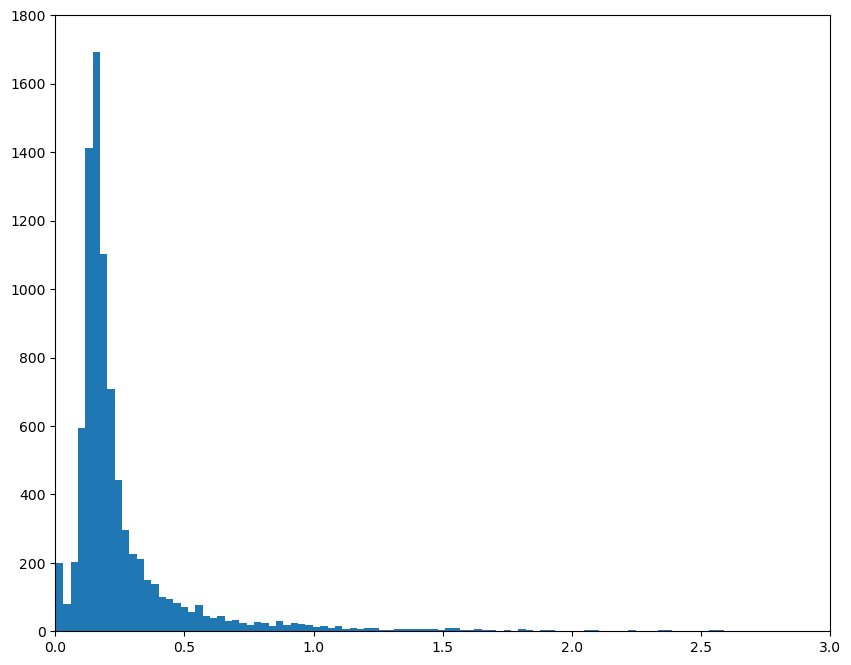

In [91]:
plt.hist(fluxerr, bins=1000)
plt.xlim(0,3)
plt.ylim(0,1800)
plt.xlabel
plt.show()

2. The mean, median, and standard deviation are displayed below

In [92]:
mean = np.mean(data)
median = np.median(data)
std = np.std(data)

print("Mean:", mean)
print("Median:", median)
print("Standard deviation:", std)

Mean: 0.0007912985
Median: 0.0
Standard deviation: 0.054868467


3. The largest outlier is 74.44648. It is 1356.8027 standard deviations from the mean.

In [93]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

In [94]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [95]:
outliers = data[(data < lower_bound) | (data > upper_bound)]

In [96]:
largest_outlier = np.max(outliers)
print("Largest outlier:", largest_outlier)

Largest outlier: 74.44648


In [97]:
x = 74.44648
z = (x - mean) / std
print("Number of standard deviations from mean:", z)

Number of standard deviations from mean: 1356.8027
